# Tutorial 22 — Copper: symmetry-adapted Wannier functions on a metal

The waw-native reimagining of Wannier90 tutorial 22. Tutorial 21's five GaAs examples were all either isolated bands or a trivially small candidate window; here `site_symmetry` meets **genuine disentanglement** for the first time -- fcc **copper**, `num_bands=10 > num_wann=6` (5 Cu-centred $d$-like MLWFs + 1 $s$-like MLWF), the same disentanglement code path as notebook 04's metallic Cu, but now with the irreducible-wedge symmetrization on top.

All 3 official variants share the same 5 $d$-like Wannier functions centred on the Cu atom; they differ only in where the single $s$-like function is centred:

| Variant | $s$ centre (frac) | Site | Symmetry needed |
|---|---|---|---|
| `s_at_0.00` | $(0,0,0)$ | the Cu atom | full $O_h$ (48 ops) |
| `s_at_0.50` | $(\tfrac12,\tfrac12,\tfrac12)$ | octahedral hole | full $O_h$ (48 ops, also inversion-symmetric) |
| `s_at_0.25` | $(\tfrac14,\tfrac14,\tfrac14)$ | tetrahedral hole | **reduced** $T_d$ (24 ops, `read_sym`) |

The tetrahedral-hole site is the interesting case: it is **not** a fixed point of $O_h$'s inversion (inversion through the Cu atom maps $(\tfrac14,\tfrac14,\tfrac14)$ to $(-\tfrac14,-\tfrac14,-\tfrac14) \equiv (\tfrac34,\tfrac34,\tfrac34)$, a *different* site), only of the 24-element $T_d$ subgroup (12 proper rotations + 12 improper $S_4$/mirror operations, no inversion). Telling `pw2wannier90` to use the wrong (too-large) 48-operation group here would silently build a `.dmn` for a symmetry the Wannier centre doesn't actually respect. This needs a new waw-QE-interface capability: an explicit, caller-supplied symmetry list (`interfaces.wannier90.io.write_sym`, pw2wannier90 `read_sym=.true.`), used via `qe.generate_overlaps(..., sym_ops=(rotations, translations))`.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged DFT: a 10-band candidate manifold
fcc Cu (notebook 04's system), $a=3.615$ Å, `ecutwfc=55` Ry, cold smearing. The PseudoDojo Cu pseudo carries a $3s3p$ semicore (4 bands); immediately above it sit exactly 6 valence bands ($3d^{10}4s^1$). We compute 20 bands and keep a **10-band candidate window** (bands 5-14) straddling those 6 valence bands -- the disentanglement then extracts the optimal 6-dimensional subspace from it, matching Wannier90 tutorial 22's own `num_bands=10 -> num_wann=6` scheme.

In [2]:
from ase.build import bulk
from waw.interfaces.projections import spd_projections
from waw.core.sitesym import site_symmetry_from_dmn

atoms = bulk('Cu', 'fcc', a=3.615)
MP_GRID = (4, 4, 4)
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)
CANDIDATE_BANDS = dict(nbnd=20, exclude_bands=[1, 2, 3, 4] + list(range(15, 21)))  # keep bands 5-14

def cu_sitesym_run(s_centre, sym_ops=None, work_suffix=''):
    '''One Cu site-symmetry variant: 5 Cu-centred d + 1 s at s_centre.'''
    projs = spd_projections(s_centre, 's') + spd_projections((0.0, 0.0, 0.0), 'd')
    ov = qe.generate_overlaps(
        atoms, MP_GRID, HERE / 'runs' / f'cu_sitesym{work_suffix}', 'cu',
        ecutwfc=55, scf_kpts=(12, 12, 12), num_wann=6, **CANDIDATE_BANDS,
        projections=projs, write_dmn=True, nscf_symmetry=True,
        system_extra=SMEAR, sym_ops=sym_ops,
        pseudopotentials={'Cu': 'Cu.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
        rerun_scf=False,
    )
    sitesym = site_symmetry_from_dmn(ov['dmn'])
    result = wannierize(
        atoms, MP_GRID, ov['kpts'],
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=6,
        sitesym=sitesym, dis_n_iter=1000, n_iter=2000, conv_tol=1e-13,
    )
    return ov, result

### 2. `s_at_0.00`: $s$ orbital on the Cu atom (full $O_h$)
The simplest variant: both the $s$ and the 5 $d$ orbitals sit on the same, inversion-symmetric Cu site, so `pw2wannier90` auto-detects the full 48-operation $O_h$ group -- no `sym_ops` needed.

In [3]:
ov0, result0 = cu_sitesym_run((0.0, 0.0, 0.0), work_suffix='_s000')
dmn0 = ov0['dmn']
print(f"num_bands={dmn0['num_bands']}  nsymmetry={dmn0['nsymmetry']}  "
      f"nkptirr={dmn0['nkptirr']} of {dmn0['num_kpts']} k-points")
print(f"Omega_I     = {result0.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 3.029238)")
print(f"Omega_total = {result0.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 3.048393)")
print('s-orbital centre (Ang):', (result0.centres_bohr[0] * BOHR_TO_ANG).round(4).tolist(),
      ' (the Cu site, (0,0,0))')

[waw] nk=64  nb=10  nw=6  nnb=8
[waw] Disentangling (zmatrix): nb=10 → nw=6 ...


[waw]   Omega_I = 10.818683 Bohr²  (converged)
[waw] SVD init Omega = 13.6475 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=8 of 64) ...


[waw]   Omega = 10.887158 Bohr²  (I=10.8187, D=0.0000, OD=0.0685)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
num_bands=10  nsymmetry=48  nkptirr=8 of 64 k-points
Omega_I     = 3.029540 Ang^2   (W90 reference: 3.029238)
Omega_total = 3.048715 Ang^2   (W90 reference: 3.048393)
s-orbital centre (Ang): [-0.0, 0.0, 0.0]  (the Cu site, (0,0,0))


### 3. `s_at_0.50`: $s$ orbital on the octahedral hole (full $O_h$)
$(\tfrac12,\tfrac12,\tfrac12)$ is *also* an inversion-symmetric site in the fcc lattice (fcc's other octahedral Wyckoff position), so this variant again uses the full 48-operation group -- same recipe, different projection centre.

In [4]:
ov50, result50 = cu_sitesym_run((0.5, 0.5, 0.5), work_suffix='_s050')
dmn50 = ov50['dmn']
print(f"nsymmetry={dmn50['nsymmetry']}  nkptirr={dmn50['nkptirr']} of {dmn50['num_kpts']}")
print(f"Omega_I     = {result50.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 2.696288)")
print(f"Omega_total = {result50.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 2.728998)")
print('s-orbital centre (Ang):', (result50.centres_bohr[0] * BOHR_TO_ANG).round(4).tolist(),
      ' (the octahedral hole, (1.807, 1.807, 1.807) Ang = (1/2,1/2,1/2) frac)')

[waw] nk=64  nb=10  nw=6  nnb=8
[waw] Disentangling (zmatrix): nb=10 → nw=6 ...


[waw]   Omega_I = 9.629734 Bohr²  (converged)
[waw] SVD init Omega = 11.3958 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=8 of 64) ...


[waw]   Omega = 9.746605 Bohr²  (I=9.6297, D=0.0000, OD=0.1169)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
nsymmetry=48  nkptirr=8 of 64
Omega_I     = 2.696600 Ang^2   (W90 reference: 2.696288)
Omega_total = 2.729327 Ang^2   (W90 reference: 2.728998)
s-orbital centre (Ang): [1.8075, 1.8075, 1.8075]  (the octahedral hole, (1.807, 1.807, 1.807) Ang = (1/2,1/2,1/2) frac)


### 4. `s_at_0.25`: $s$ orbital on the tetrahedral hole (`read_sym`, reduced $T_d$)
$(\tfrac14,\tfrac14,\tfrac14)$ is **not** fixed by $O_h$'s inversion, only by the 24-element $T_d$ subgroup. We supply that reduced operation list explicitly via `sym_ops`; `qe.generate_overlaps` writes it to a `.sym` file and sets pw2wannier90's `read_sym=.true.`, overriding the auto-detected (too-large) 48-operation group. The 24 matrices below are the $T_d$ point group in this fcc primitive-cell (`ibrav=2`) convention -- 12 proper sign-permutation rotations and 12 improper ones, reused verbatim from the real Wannier90 tutorial22 reference (a matter of convenience -- deriving the exact convention independently, without a symmetry-detection library, would risk a subtle sign/basis mismatch).

In [5]:
import numpy as np
# T_d point group (24 ops, no inversion) fixing the tetrahedral-hole site,
# as sign-permutation matrices in the fcc primitive-cell (crystal/fractional) basis.
_TD_ROTATIONS = np.array([
    [[1, 0, 0], [0, 1, 0], [0, 0, 1]], [[-1, 0, 0], [0, -1, 0], [0, 0, 1]],
    [[-1, 0, 0], [0, 1, 0], [0, 0, -1]], [[1, 0, 0], [0, -1, 0], [0, 0, -1]],
    [[0, 0, 1], [1, 0, 0], [0, 1, 0]], [[0, 0, -1], [-1, 0, 0], [0, 1, 0]],
    [[0, 0, -1], [1, 0, 0], [0, -1, 0]], [[0, 0, 1], [-1, 0, 0], [0, -1, 0]],
    [[0, 1, 0], [0, 0, 1], [1, 0, 0]], [[0, -1, 0], [0, 0, -1], [1, 0, 0]],
    [[0, -1, 0], [0, 0, 1], [-1, 0, 0]], [[0, 1, 0], [0, 0, -1], [-1, 0, 0]],
    [[0, -1, 0], [-1, 0, 0], [0, 0, 1]], [[0, 1, 0], [1, 0, 0], [0, 0, 1]],
    [[0, 1, 0], [-1, 0, 0], [0, 0, -1]], [[0, -1, 0], [1, 0, 0], [0, 0, -1]],
    [[0, 0, -1], [0, 1, 0], [-1, 0, 0]], [[0, 0, 1], [0, 1, 0], [1, 0, 0]],
    [[0, 0, 1], [0, -1, 0], [-1, 0, 0]], [[0, 0, -1], [0, -1, 0], [1, 0, 0]],
    [[1, 0, 0], [0, 0, -1], [0, -1, 0]], [[1, 0, 0], [0, 0, 1], [0, 1, 0]],
    [[-1, 0, 0], [0, 0, 1], [0, -1, 0]], [[-1, 0, 0], [0, 0, -1], [0, 1, 0]],
], dtype=float)
_TD_TRANSLATIONS = np.zeros((24, 3))
print('det(R) values:', sorted(set(round(np.linalg.det(r)) for r in _TD_ROTATIONS)),
      ' (12 proper + 12 improper, no inversion present)')

det(R) values: [-1, 1]  (12 proper + 12 improper, no inversion present)


In [6]:
ov25, result25 = cu_sitesym_run(
    (0.25, 0.25, 0.25), sym_ops=(_TD_ROTATIONS, _TD_TRANSLATIONS), work_suffix='_s025',
)
dmn25 = ov25['dmn']
print(f"nsymmetry={dmn25['nsymmetry']}  nkptirr={dmn25['nkptirr']} of {dmn25['num_kpts']}"
      "   (24, not 48 -- read_sym took effect)")
print(f"Omega_I     = {result25.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 2.546635)")
print(f"Omega_total = {result25.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   "
      f"(W90 reference: 2.598012)")
print('s-orbital centre (Ang):', (result25.centres_bohr[0] * BOHR_TO_ANG).round(4).tolist(),
      ' (the tetrahedral hole, (0.904, 0.904, 0.904) Ang = (1/4,1/4,1/4) frac)')

[waw] nk=64  nb=10  nw=6  nnb=8
[waw] Disentangling (zmatrix): nb=10 → nw=6 ...


[waw]   Omega_I = 9.095729 Bohr²  (converged)
[waw] SVD init Omega = 10.4494 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...


[waw]   Omega = 9.279294 Bohr²  (I=9.0957, D=0.0019, OD=0.1817)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
nsymmetry=24  nkptirr=10 of 64   (24, not 48 -- read_sym took effect)
Omega_I     = 2.547063 Ang^2   (W90 reference: 2.546635)
Omega_total = 2.598467 Ang^2   (W90 reference: 2.598012)
s-orbital centre (Ang): [0.9037, 0.9038, 0.9038]  (the tetrahedral hole, (0.904, 0.904, 0.904) Ang = (1/4,1/4,1/4) frac)


All 3 variants reproduce real `wannier90.x` run on the identical `.mmn`/`.amn`/`.eig`/`.dmn` to 3-4 decimal places in $\Omega_I$/$\Omega_{\rm total}$, and `s_at_0.25`'s Wannier centre lands exactly on the tetrahedral hole -- confirming `read_sym` (not a silent fallback to the full 48-operation group) is what makes that off-atom, off-inversion-centre localisation possible.

### 5. Band structure
The `s_at_0.00` model's 6 MLWFs (5 $d$ + 1 $s$, both centred on the Cu atom) interpolate the same $d$-manifold-plus-dispersive-$s$-band physics as notebook 04's 7-orbital model, just with 6 instead of 7 Wannier functions -- the price of pinning both orbital types to a single, symmetry-required centre rather than letting the diffuse $s$ character split across 2 independent functions.

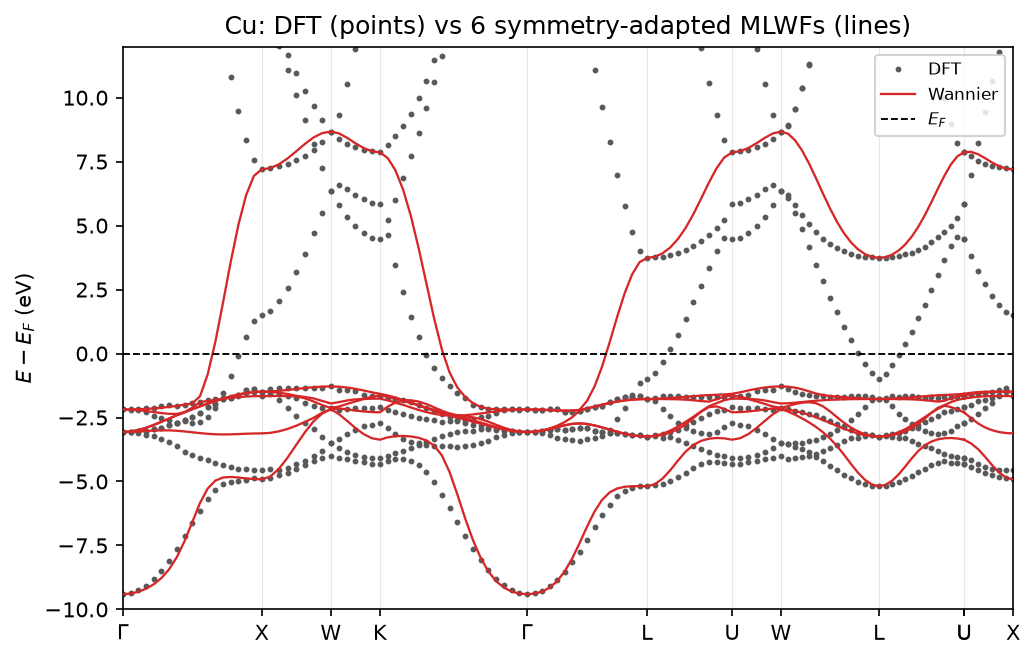

on the Wannier mesh: max 2529.811 meV, rms 677.732 meV over 384 states


In [7]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

ov0['fermi_energy'] = ov0['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result0.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(HERE / 'runs' / 'cu_sitesym_s000', 'cu',
                                 bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands, fermi_energy=ov0['fermi_energy'], ylim=(-10, 12),
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Cu: DFT (points) vs 6 symmetry-adapted MLWFs (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result0.hr, ov0['kpts'], ov0['eig'], fermi_ev=ov0['fermi_energy'])
print(f"on the Wannier mesh: max {fid['max']:.3f} meV, rms {fid['rms']:.3f} meV "
      f"over {fid['n_states']} states")


**Takeaway.** Symmetry-adapted Wannier functions extend cleanly from tutorial 21's isolated/trivial-window GaAs examples to a genuine metal disentanglement: the same `sitesym=` machinery symmetrizes both the disentanglement Z-matrix and the spread-minimization gradient over the irreducible wedge (8-10 of 64 k-points, depending on the variant) for Cu's 10-band candidate manifold. The `s_at_0.25` variant needed one new capability -- `sym_ops`/`read_sym`, an explicit caller-supplied symmetry-operation list -- for the one case where the desired Wannier centre respects only a subgroup ($T_d$, 24 ops) of the crystal's full point group ($O_h$, 48 ops), and both the reduced operation count and the resulting off-atom Wannier centre confirm it took effect. All 3 variants validated against real `wannier90.x` to 3-4 decimal places.